# Torch Batteries Example: Ames Housing With Two Targets

This example trains one network to predict both `SalePrice` (regression) and `BldgType` (classification) from the [Ames Iowa Housing Data on Kaggle](https://www.kaggle.com/datasets/marcopale/housing). It demonstrates DataPack preparation and loader setup, structured step outputs with metric selectors, and phase-specific metrics.

[DataPack guide](https://michalszc.github.io/torch-batteries/guides/data-pack/) · [Metrics guide](https://michalszc.github.io/torch-batteries/guides/metrics/) · [Training guide](https://michalszc.github.io/torch-batteries/guides/training/)

## 0. Prerequisites

Use Python 3.12 or newer. The example extra provides `kagglehub`, pandas, scikit-learn, and plotting packages. The next cell installs it for a fresh notebook environment. Kagglehub caches the download for later runs.

In [ ]:
%pip install "torch-batteries[example]"

## 1. Setup

Import the public DataPack, event, training, and metric APIs, then record the installed version.

In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch_batteries
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset

from torch_batteries import (Battery, DataContext, DataLoaderConfig, DataPack, DatasetBundle, Event, EventContext, StepOutput, charge)
from torch_batteries.utils.metrics import CollectedMetric, MetricSpec

SEED = 17
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"torch-batteries version: {torch_batteries.__version__}")
print(f"PyTorch version: {torch.__version__}")

torch-batteries version: 1.0.0
PyTorch version: 2.10.0


## 2. Download and prepare the data with DataPack

The [DataPack lifecycle](https://michalszc.github.io/torch-batteries/guides/data-pack/) downloads and prepares data in `PREPARE_DATA`, supplies phase datasets through `DatasetBundle` in `SETUP_DATA`, and configures batch sizes through `CONFIGURE_DATALOADER`. Kaggle calls the building target `Bldg Type`; we rename it for the model API. We split before fitting imputation, scaling, and category encoding so validation and test rows cannot influence training preparation. `Order` and `PID` are identifiers, and both targets are excluded from the features. DataPack also creates the normalized log-price target using training rows only and provides the inverse transformation to the dollar-denominated metric.

In [2]:
class HousingDataPack(DataPack):
    seed = SEED

    def __init__(self):
        self.datasets = {}
        self.input_features = 0
        self.class_names = []
        self.price_mean = 0.0
        self.price_std = 1.0

    @charge(Event.PREPARE_DATA)
    def prepare(self, context: DataContext):
        dataset_dir = Path(kagglehub.dataset_download("marcopale/housing", output_dir="data/ames_housing"))
        frame = pd.read_csv(dataset_dir / "AmesHousing.csv").rename(columns={"Bldg Type": "BldgType"})
        features = frame.drop(columns=["Order", "PID", "SalePrice", "BldgType"])
        prices = frame["SalePrice"].to_numpy(dtype=np.float32)
        self.class_names = sorted(frame["BldgType"].unique())
        class_ids = frame["BldgType"].map({name: index for index, name in enumerate(self.class_names)}).to_numpy(dtype=np.int64)

        indices = np.arange(len(frame))
        train_idx, remaining_idx = train_test_split(indices, test_size=0.30, random_state=context["seed"], stratify=class_ids)
        val_idx, test_idx = train_test_split(remaining_idx, test_size=0.50, random_state=context["seed"], stratify=class_ids[remaining_idx])
        numeric_columns = features.select_dtypes(include=np.number).columns.tolist()
        categorical_columns = features.columns.difference(numeric_columns).tolist()
        preprocessor = ColumnTransformer([
            ("numeric", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_columns),
            ("categorical", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_columns),
        ])
        x_train = preprocessor.fit_transform(features.iloc[train_idx]).astype(np.float32)
        x_val = preprocessor.transform(features.iloc[val_idx]).astype(np.float32)
        x_test = preprocessor.transform(features.iloc[test_idx]).astype(np.float32)
        train_log_price = np.log1p(prices[train_idx])
        self.price_mean = float(train_log_price.mean())
        self.price_std = float(train_log_price.std())
        self.input_features = x_train.shape[1]

        def make_dataset(values, indices):
            normalized_price = (np.log1p(prices[indices]) - self.price_mean) / self.price_std
            return TensorDataset(
                torch.from_numpy(values),
                torch.from_numpy(normalized_price.astype(np.float32)),
                torch.from_numpy(class_ids[indices]),
            )

        self.datasets = {
            "train": make_dataset(x_train, train_idx),
            "validation": make_dataset(x_val, val_idx),
            "test": make_dataset(x_test, test_idx),
        }

    @charge(Event.SETUP_DATA)
    def setup(self, context: DataContext):
        if context["stage"] == "fit":
            return DatasetBundle(train=self.datasets["train"], validation=self.datasets["validation"])
        return DatasetBundle(test=self.datasets["test"])

    @charge(Event.CONFIGURE_DATALOADER)
    def configure(self, context: DataContext):
        return DataLoaderConfig(batch_size=64)


data_pack = HousingDataPack()
with data_pack.resolve("fit") as resolved:
    print(f"Rows: train={len(resolved.datasets.train)}, validation={len(resolved.datasets.validation)}, test={len(data_pack.datasets['test'])}")
    print(f"Features after encoding: {data_pack.input_features}; building classes: {data_pack.class_names}")

Rows: train=2051, validation=439, test=440
Features after encoding: 289; building classes: ['1Fam', '2fmCon', 'Duplex', 'Twnhs', 'TwnhsE']


## 3. Define a shared model and structured metrics

Two shared hidden layers feed separate price and building-type branches, each with its own hidden layers. DataPack has already prepared the regression target, so the model contains no price transformation parameters. Dropout and a robust Smooth L1 price loss reduce sensitivity to unusually priced homes; the price loss receives twice the classification weight. The [StepOutput](https://michalszc.github.io/torch-batteries/reference/results-and-errors/) holds a prediction and target dictionary. [MetricSpec](https://michalszc.github.io/torch-batteries/reference/metrics/) routes each metric to its matching keys. Validation alone computes macro F1 with [CollectedMetric](https://michalszc.github.io/torch-batteries/guides/metrics/), which collects the whole phase before evaluating it.

In [3]:
from torch_batteries.callbacks import EarlyStopping


class HousingModel(nn.Module):
    def __init__(self, input_features, n_classes):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_features, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 128), nn.ReLU(),
        )
        self.price_head = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.1), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))
        self.class_head = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, n_classes))

    def forward(self, values):
        hidden = self.shared(values)
        return self.price_head(hidden).squeeze(1), self.class_head(hidden)

    def _step(self, context):
        values, normalized_target, building = context["batch"]
        normalized_price, logits = self(values)
        loss = 2.0 * F.smooth_l1_loss(normalized_price, normalized_target, beta=0.2) + F.cross_entropy(logits, building)
        return StepOutput(
            loss=loss,
            predictions={"regression": normalized_price, "classification": logits},
            targets={"regression": normalized_target, "classification": building},
        )

    @charge(Event.TRAIN_STEP)
    def train_step(self, context: EventContext):
        return self._step(context)

    @charge(Event.VALIDATION_STEP)
    def validation_step(self, context: EventContext):
        return self._step(context)

    @charge(Event.TEST_STEP)
    def test_step(self, context: EventContext):
        return self._step(context)


def accuracy(predictions, targets):
    return (predictions.argmax(dim=1) == targets).float().mean()

def mae_dollars(predictions, targets):
    predicted_dollars = torch.expm1(predictions * data_pack.price_std + data_pack.price_mean)
    target_dollars = torch.expm1(targets * data_pack.price_std + data_pack.price_mean)
    return (predicted_dollars - target_dollars).abs().mean()

def macro_f1(predictions, targets):
    return f1_score(targets.numpy(), predictions.argmax(dim=1).numpy(), average="macro")

classification = lambda metric: MetricSpec(metric, predictions="classification", targets="classification")
regression = lambda metric: MetricSpec(metric, predictions="regression", targets="regression")
common_metrics = {"accuracy": classification(accuracy), "mae_dollars": regression(mae_dollars)}
model = HousingModel(data_pack.input_features, len(data_pack.class_names))
early_stopping = EarlyStopping(
    phase="validation", metric="mae_dollars", mode="min",
    patience=10, min_delta=100, restore_best_weights=True,
)
battery = Battery(
    model, optimizer=torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4), device="cpu",
    callbacks=[early_stopping],
    data_pack=data_pack,
    metrics={
        "train": common_metrics,
        "validation": {**common_metrics, "macro_f1": classification(CollectedMetric(macro_f1))},
        "test": common_metrics,
    },
)

## 4. Train and validate

[`fit()`](https://michalszc.github.io/torch-batteries/reference/trainer/) gets its loaders from the DataPack. It returns loss and metric histories for each phase plus execution metadata. Since each phase uses one dataset, metric names are plain names. [EarlyStopping](https://michalszc.github.io/torch-batteries/reference/callbacks/) monitors validation MAE in dollars and restores the best model weights; training runs for at most 60 epochs.

In [4]:
history = battery.fit(epochs=60, verbose=1)
print(f"Epochs: {history['epochs_completed']}; optimizer steps: {history['optimizer_steps']}")
print(f"Final train accuracy: {history['train_metrics']['accuracy'][-1]:.3f}")
print(f"Final validation accuracy: {history['val_metrics']['accuracy'][-1]:.3f}")
print(f"Final validation macro F1: {history['val_metrics']['macro_f1'][-1]:.3f}")
print(f"Best validation MAE: ${early_stopping.best_score:,.0f}")
print(f"Stopped early: {history['stopped_early']}; reason: {history['stop_reason']}")

Epoch 29/60 [Validation]: 100%|██████████| 7/7 [00:00<00:00, 1151.33it/s, Loss=0.3214, Accuracy=0.9704, Mae_dollars=14363.7524]


Epochs: 29; optimizer steps: 957
Final train accuracy: 0.986
Final validation accuracy: 0.970
Final validation macro F1: 0.880
Best validation MAE: $13,411
Stopped early: True; reason: Early stopping: validation metric 'mae_dollars' did not improve for 10 checks (best=13410.886858894504, latest=14363.75236466045)


## 5. Test both tasks

[`test()`](https://michalszc.github.io/torch-batteries/reference/trainer/) resolves the held-out test dataset from the same DataPack. The metric selectors evaluate each head against the correct target. `test_loss` is the sample-weighted joint objective.

In [5]:
result = battery.test(verbose=1)
print(f"Test loss: {result['test_loss']:.3f}")
print(f"Test building accuracy: {result['test_metrics']['accuracy']:.3f}")
print(f"Test price MAE: ${result['test_metrics']['mae_dollars']:,.0f}")

Epoch 1/1 [Test]: 100%|██████████| 7/7 [00:00<00:00, 1041.84it/s, Loss=0.3228, Accuracy=0.9636, Mae_dollars=12159.1821]

Test loss: 0.323
Test building accuracy: 0.964
Test price MAE: $12,159


## 6. Compare learning curves

Price MAE is in dollars, while accuracy is a fraction. Separate panels keep both scales readable.

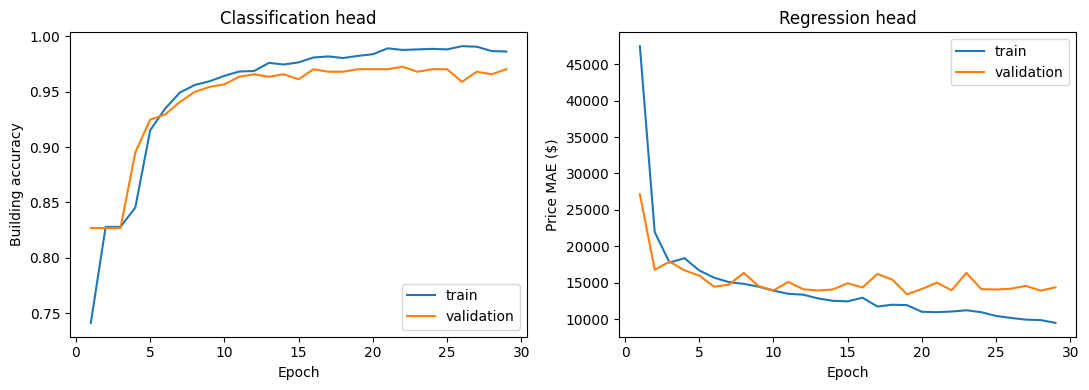

In [6]:
epochs = np.arange(1, history['epochs_completed'] + 1)
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, history['train_metrics']['accuracy'], label='train')
axes[0].plot(epochs, history['val_metrics']['accuracy'], label='validation')
axes[0].set(xlabel='Epoch', ylabel='Building accuracy', title='Classification head')
axes[0].legend()
axes[1].plot(epochs, history['train_metrics']['mae_dollars'], label='train')
axes[1].plot(epochs, history['val_metrics']['mae_dollars'], label='validation')
axes[1].set(xlabel='Epoch', ylabel='Price MAE ($)', title='Regression head')
axes[1].legend()
figure.tight_layout()
plt.show()